# Gaussian Splatting Initialization Experiments

**Goal**: Achieve >26 dB PSNR from initialization alone (no training) with ~100k Gaussians.

**Key insight**: With only ~1° angular range, a flat layer of Gaussians whose colors match
the projection pixel values should produce near-perfect renders.

**Strategies tested**:
1. Flat grid + pixel-value colors from the middle projection
2. Grid search over opacity & scale to find optimal rendering parameters
3. Calibrated initialization: render → compute correction → adjust colors

In [1]:
import sys, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from gsplat import rasterization

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from gsplat_compress import GaussianParams
from inct.dataset_slices import ProjectionSliceDataset

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")


Device: cuda  |  PyTorch 2.10.0+cu128
GPU: NVIDIA A100 80GB PCIe


## 1. Load Dataset & Setup Cameras

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 10
START_PROJECTION = 0
TARGET_SIZE = (2560//2, 2160//2)

# ── Load dataset ──────────────────────────────────────────────────────────
dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    start_projection=START_PROJECTION,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=False,
)

TOTAL_PROJECTIONS = dataset.processor.num_projections
volume = dataset.get_full_volume()  # (H, W, N_proj)
H, W, N_PROJ = volume.shape

# ── Global normalization to [0, 1] ───────────────────────────────────────
v_min, v_max = volume.min(), volume.max()
projections = (volume - v_min) / (v_max - v_min + 1e-8)
projections = projections.permute(2, 0, 1)  # [N_PROJ, H, W]
gt_projections = projections.unsqueeze(-1).repeat(1, 1, 1, 3).to(device)

print(f"\nLoaded {N_PROJ} projections (indices {START_PROJECTION}–{START_PROJECTION + N_PROJ - 1} "
      f"of {TOTAL_PROJECTIONS} total), each {H}×{W}")
print(f"Value range: [{projections.min():.4f}, {projections.max():.4f}]")

# ── Camera setup ──────────────────────────────────────────────────────────
SIZE = float(max(H, W))

def ct_cameras(n_proj, size, device, start_proj=0, total_n_proj=None,
               img_W=None, img_H=None):
    if total_n_proj is None:
        total_n_proj = n_proj
    all_angles = torch.linspace(0, math.pi, total_n_proj + 1, device=device)[:-1]
    angles = all_angles[start_proj : start_proj + n_proj]

    K = torch.eye(3, device=device)
    K[0, 2] = (img_W / 2.0) if img_W is not None else (size / 2.0)
    K[1, 2] = (img_H / 2.0) if img_H is not None else (size / 2.0)

    c = torch.cos(angles)
    s = torch.sin(angles)
    viewmats = torch.zeros(n_proj, 4, 4, device=device)
    viewmats[:, 0, 0] = c
    viewmats[:, 0, 1] = s
    viewmats[:, 1, 2] = -1.0
    viewmats[:, 2, 0] = -s
    viewmats[:, 2, 1] = c
    viewmats[:, 2, 3] = size
    viewmats[:, 3, 3] = 1.0
    return viewmats, K, angles

viewmats_all, K_cam, angles_all = ct_cameras(
    N_PROJ, SIZE, device,
    start_proj=START_PROJECTION,
    total_n_proj=TOTAL_PROJECTIONS,
    img_W=W, img_H=H,
)
Ks_all = K_cam[None].expand(N_PROJ, -1, -1)

angle_start_deg = angles_all[0].item() * 180 / math.pi
angle_end_deg   = angles_all[-1].item() * 180 / math.pi
mid_idx = N_PROJ // 2
mid_angle = angles_all[mid_idx].item()
print(f"Cameras: {N_PROJ} views, angles [{angle_start_deg:.2f}°, {angle_end_deg:.2f}°]")
print(f"Middle projection: idx={mid_idx}, angle={mid_angle*180/math.pi:.2f}°")
print(f"SIZE={SIZE}, H={H}, W={W}")


✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [6814.0000, 51523.0000]
ProjectionSliceDataset:
  Volume shape: (1080, 1280, 10)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,382,400
Loading 10 projections...
Volume shape: (1080, 1280, 10)
Total voxels: 13,824,000
Value range: [8992.6250, 46449.3125]

Loaded 10 projections (indices 0–9 of 1501 total), each 1080×1280
Value range: [0.0000, 1.0000]
Cameras: 10 views, angles [0.00°, 1.08°]
Middle projection: idx=5, angle=0.60°
SIZE=1280.0, H=1080, W=1280


## 2. Rendering & Evaluation Helpers

In [4]:
def render_ct(means, log_scales, quats, rgbs, opacities,
              viewmats, Ks, W, H, near_plane=0.01, far_plane=1e4):
    """Render orthographic CT projections from multiple viewpoints."""
    scales = torch.exp(log_scales)
    colors = torch.sigmoid(rgbs)
    opac = torch.sigmoid(opacities)
    q = quats / quats.norm(dim=-1, keepdim=True)

    renders, alphas, info = rasterization(
        means=means, quats=q, scales=scales, opacities=opac, colors=colors,
        viewmats=viewmats, Ks=Ks, width=W, height=H,
        near_plane=near_plane, far_plane=far_plane,
        packed=False, camera_model="ortho",
    )
    return renders, alphas, info


def evaluate_init(params, viewmats, Ks, gt_projs, W, H, label="Init"):
    """Render all projections and compute per-view + average PSNR."""
    N = viewmats.shape[0]
    BATCH = 4
    all_renders = []
    with torch.no_grad():
        for s in range(0, N, BATCH):
            e = min(s + BATCH, N)
            r, _, _ = render_ct(
                params.means, params.log_scales, params.quats,
                params.rgbs, params.opacities,
                viewmats[s:e], Ks[s:e], W, H,
            )
            all_renders.append(r.cpu())
    all_renders = torch.cat(all_renders, dim=0)  # [N, H, W, 3]

    gt_cpu = gt_projs.cpu()
    mse_per = ((all_renders - gt_cpu) ** 2).mean(dim=(1, 2, 3))
    psnr_per = -10 * torch.log10(mse_per + 1e-10)
    avg_psnr = psnr_per.mean().item()
    avg_mse = mse_per.mean().item()

    print(f"[{label}]  Avg PSNR = {avg_psnr:.2f} dB  |  "
          f"Min = {psnr_per.min().item():.2f}  Max = {psnr_per.max().item():.2f}  |  "
          f"MSE = {avg_mse:.6f}")
    return all_renders, psnr_per, avg_psnr


def show_comparison(renders, gt_projs_cpu, psnr_per, title="", n_show=5):
    """Show GT vs rendered vs error for a few projections."""
    N = renders.shape[0]
    idxs = np.linspace(0, N - 1, min(n_show, N), dtype=int)
    fig, axes = plt.subplots(3, len(idxs), figsize=(3.5 * len(idxs), 9))
    if len(idxs) == 1:
        axes = axes[:, None]
    for j, idx in enumerate(idxs):
        gt = gt_projs_cpu[idx, :, :, 0].numpy()
        rd = np.clip(renders[idx, :, :, 0].numpy(), 0, 1)
        err = np.abs(rd - gt)
        axes[0, j].imshow(gt, cmap='gray', vmin=0, vmax=1)
        axes[0, j].set_title(f'GT #{idx}', fontsize=9); axes[0, j].axis('off')
        axes[1, j].imshow(rd, cmap='gray', vmin=0, vmax=1)
        axes[1, j].set_title(f'Render ({psnr_per[idx]:.1f} dB)', fontsize=9); axes[1, j].axis('off')
        axes[2, j].imshow(err, cmap='hot', vmin=0, vmax=0.1)
        axes[2, j].set_title('|Error|', fontsize=9); axes[2, j].axis('off')
    axes[0, 0].set_ylabel('Target'); axes[1, 0].set_ylabel('Render'); axes[2, 0].set_ylabel('Error')
    plt.suptitle(f'{title}\nAvg PSNR = {psnr_per.mean():.2f} dB', fontsize=12)
    plt.tight_layout(); plt.show()

print("Helpers ready")

Helpers ready


## 3. Initialization Strategy: Back-Projected Pixel Grid

**Approach**: Place Gaussians on a uniform grid in the image space of the **middle** projection,
then back-project along rays to find their 3D positions on the plane perpendicular to the
middle viewing direction. Since the angular range is tiny (~1°), this flat sheet of Gaussians
is nearly optimal.

**Color initialization**: Sample each Gaussian's intensity from the middle projection at its
pixel location. This way, the initial render from the middle view is nearly pixel-perfect.

**Key parameters to tune**: opacity, scale (sigma), and the interaction between them determines
whether the flat sheet renders as a clean image or as a blurry/spotty mess.

In [5]:
def init_backproject_flat(n_points, img_H, img_W, size, device,
                         ref_projection, ref_angle,
                         init_scale=None, init_opacity=0.5,
                         seed=42):
    """Initialize Gaussians on a flat grid back-projected from a reference projection.
    
    Each Gaussian sits on the plane orthogonal to the viewing direction of the
    reference projection, at a position corresponding to a uniform pixel grid.
    Colors are sampled directly from the reference projection image.
    
    Parameters
    ----------
    n_points : int - target number of Gaussians
    img_H, img_W : int - image dimensions in pixels
    size : float - world extent (max(H,W))
    device : torch.device
    ref_projection : Tensor [H, W] - reference projection image (values in [0,1])
    ref_angle : float - angle of the reference projection (radians)
    init_scale : float or None - Gaussian sigma; None = auto from grid spacing
    init_opacity : float - initial opacity (before sigmoid)
    seed : int
    
    Returns
    -------
    params : GaussianParams
    """
    torch.manual_seed(seed)
    cx = img_W / 2.0
    cy = img_H / 2.0
    
    # ── Grid dimensions matching image aspect ratio ────────────────
    aspect = img_W / img_H
    n_rows = max(2, int(math.sqrt(n_points / aspect)))
    n_cols = max(2, int(n_points / n_rows))
    actual_n = n_rows * n_cols
    
    # Pixel centres covering the full image
    cols = torch.linspace(0.5, img_W - 0.5, n_cols, device=device)
    rows = torch.linspace(0.5, img_H - 0.5, n_rows, device=device)
    gc, gr = torch.meshgrid(cols, rows, indexing='xy')  # [n_cols, n_rows]
    col_flat = gc.reshape(-1).float()  # [N]
    row_flat = gr.reshape(-1).float()  # [N]
    
    # ── Back-project pixel → 3D world (orthographic) ──────────────
    # At the reference angle θ₀, the orthographic camera has:
    #   x_cam = col - cx →  world: wx = (col-cx)*cosθ₀ ,  wy = (col-cx)*sinθ₀
    #   y_cam = row - cy →  world: wz = cy - row  (y_cam = -wz)
    # Gaussians are placed on the mid-depth plane (z_cam = size, the camera translation)
    c0 = math.cos(ref_angle)
    s0 = math.sin(ref_angle)
    wx = (col_flat - cx) * c0
    wy = (col_flat - cx) * s0
    wz = cy - row_flat
    means = torch.stack([wx, wy, wz], dim=-1)  # [N, 3]
    
    # ── Auto-scale from grid spacing ──────────────────────────────
    if init_scale is None:
        pixel_spacing = math.sqrt(img_W * img_H / actual_n)
        init_scale = 0.9 * pixel_spacing
    
    # ── Sample colors from the reference projection ───────────────
    # Bilinear interpolation at grid positions
    # grid_sample expects input [1,1,N,2] with coords in [-1,1]
    norm_x = (col_flat / img_W) * 2 - 1  # [-1, 1]
    norm_y = (row_flat / img_H) * 2 - 1  # [-1, 1]
    grid_coords = torch.stack([norm_x, norm_y], dim=-1).unsqueeze(0).unsqueeze(0)  # [1,1,N,2]
    ref_img = ref_projection.unsqueeze(0).unsqueeze(0)  # [1,1,H,W]
    sampled_vals = F.grid_sample(ref_img, grid_coords, mode='bilinear', 
                                  padding_mode='border', align_corners=False)
    sampled_vals = sampled_vals.squeeze()  # [N]
    
    # Convert sampled intensities to logit-space RGB (sigmoid^{-1})
    sampled_clamped = sampled_vals.clamp(0.01, 0.99)
    rgb_logit = torch.log(sampled_clamped / (1 - sampled_clamped))
    rgbs = rgb_logit.unsqueeze(-1).expand(-1, 3).clone()  # [N, 3]
    
    # ── Build params ──────────────────────────────────────────────
    N = means.shape[0]
    log_scales = torch.full((N, 3), math.log(init_scale), device=device)
    quats = torch.zeros(N, 4, device=device); quats[:, 0] = 1.0
    opacities = torch.logit(torch.full((N,), init_opacity, device=device).clamp(0.01, 0.99))
    
    params = GaussianParams(means, log_scales, quats, rgbs, opacities)
    params.means.requires_grad_(True)
    params.log_scales.requires_grad_(True)
    params.rgbs.requires_grad_(True)
    params.opacities.requires_grad_(True)
    
    pixel_spacing_actual = math.sqrt(img_W * img_H / actual_n)
    print(f"Initialized {actual_n:,} Gaussians (backproject-flat)")
    print(f"  Grid: {n_cols}×{n_rows}, pixel spacing ≈ {pixel_spacing_actual:.2f} px")
    print(f"  Scale σ = {init_scale:.2f} px, opacity = {init_opacity}")
    print(f"  Ref angle = {ref_angle*180/math.pi:.2f}°, colors sampled from projection")
    return params

print("init_backproject_flat ready")

init_backproject_flat ready


## 4. Experiment A: Grid Search over Opacity & Scale

The rendering equation for overlapping Gaussians means the final pixel value depends on the 
interaction of opacity and Gaussian spread. We search for the best (opacity, scale) combo
that maximizes PSNR at initialization.

In [6]:
N_POINTS = 100_000

# Use the middle projection as reference
ref_proj = projections[mid_idx].to(device)  # [H, W]

# ── Grid search over opacity and scale ────────────────────────────────────
opacities_to_try = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
scales_to_try = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]

results = []
best_psnr = -1
best_config = None

print(f"Grid search: {len(opacities_to_try)} opacities × {len(scales_to_try)} scales = "
      f"{len(opacities_to_try) * len(scales_to_try)} configs")
print("=" * 70)

for opacity in opacities_to_try:
    for scale in scales_to_try:
        params = init_backproject_flat(
            N_POINTS, H, W, SIZE, device,
            ref_projection=ref_proj,
            ref_angle=mid_angle,
            init_scale=scale,
            init_opacity=opacity,
        )
        # Quick eval on just the middle projection for speed
        with torch.no_grad():
            r, _, _ = render_ct(
                params.means, params.log_scales, params.quats,
                params.rgbs, params.opacities,
                viewmats_all[mid_idx:mid_idx+1], Ks_all[mid_idx:mid_idx+1], W, H,
            )
            mse = ((r[0, :, :, 0].cpu() - projections[mid_idx]) ** 2).mean().item()
            psnr = -10 * math.log10(mse + 1e-10)
        
        results.append((opacity, scale, psnr))
        if psnr > best_psnr:
            best_psnr = psnr
            best_config = (opacity, scale)

print(f"\n{'=' * 70}")
print(f"Best config: opacity={best_config[0]}, scale={best_config[1]}, "
      f"PSNR={best_psnr:.2f} dB (on middle projection)")

# Show top 10
results.sort(key=lambda x: -x[2])
print(f"\nTop 10 configurations:")
for i, (op, sc, p) in enumerate(results[:10]):
    print(f"  {i+1}. opacity={op:.2f}, scale={sc:.1f} → PSNR={p:.2f} dB")

Grid search: 9 opacities × 7 scales = 63 configs
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 0.50 px, opacity = 0.05
  Ref angle = 0.60°, colors sampled from projection


Output()

gsplat: CUDA extension has been set up successfully in 93.04 seconds.

Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 1.00 px, opacity = 0.05
  Ref angle = 0.60°, colors sampled from projection
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 1.50 px, opacity = 0.05
  Ref angle = 0.60°, colors sampled from projection
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 2.00 px, opacity = 0.05
  Ref angle = 0.60°, colors sampled from projection
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 3.00 px, opacity = 0.05
  Ref angle = 0.60°, colors sampled from projection
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 4.00 px, opacity = 0.05
  Ref angle = 0.60°, colors sampled from projection
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 5.00 px, opaci

## 5. Visualize Grid Search Results

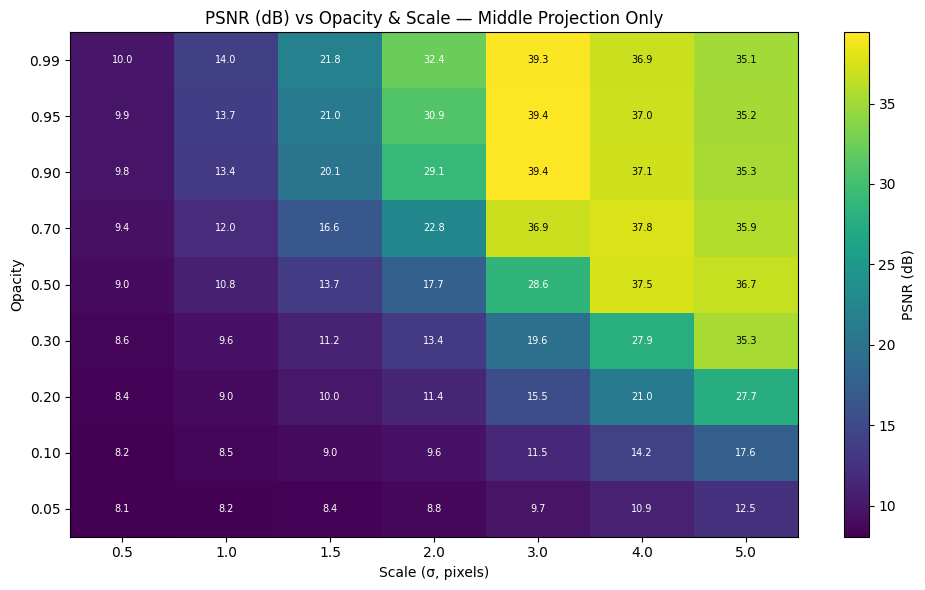

In [7]:
# ── Heatmap of PSNR vs (opacity, scale) ───────────────────────────────────
psnr_grid = np.zeros((len(opacities_to_try), len(scales_to_try)))
for op, sc, p in results:
    i = opacities_to_try.index(op)
    j = scales_to_try.index(sc)
    psnr_grid[i, j] = p

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(psnr_grid, aspect='auto', origin='lower', cmap='viridis')
ax.set_xticks(range(len(scales_to_try)))
ax.set_xticklabels([f'{s:.1f}' for s in scales_to_try])
ax.set_yticks(range(len(opacities_to_try)))
ax.set_yticklabels([f'{o:.2f}' for o in opacities_to_try])
ax.set_xlabel('Scale (σ, pixels)')
ax.set_ylabel('Opacity')
ax.set_title('PSNR (dB) vs Opacity & Scale — Middle Projection Only')

# Annotate each cell
for i in range(len(opacities_to_try)):
    for j in range(len(scales_to_try)):
        color = 'white' if psnr_grid[i, j] < psnr_grid.max() - 5 else 'black'
        ax.text(j, i, f'{psnr_grid[i,j]:.1f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, label='PSNR (dB)')
plt.tight_layout(); plt.show()

## 6. Full Evaluation with Best Config

Evaluate the best (opacity, scale) on **all** projections, not just the middle one.

Using best config: opacity=0.9, scale=3.0
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 3.00 px, opacity = 0.9
  Ref angle = 0.60°, colors sampled from projection
[Exp A: Best Grid Search]  Avg PSNR = 37.79 dB  |  Min = 36.97  Max = 39.43  |  MSE = 0.000168


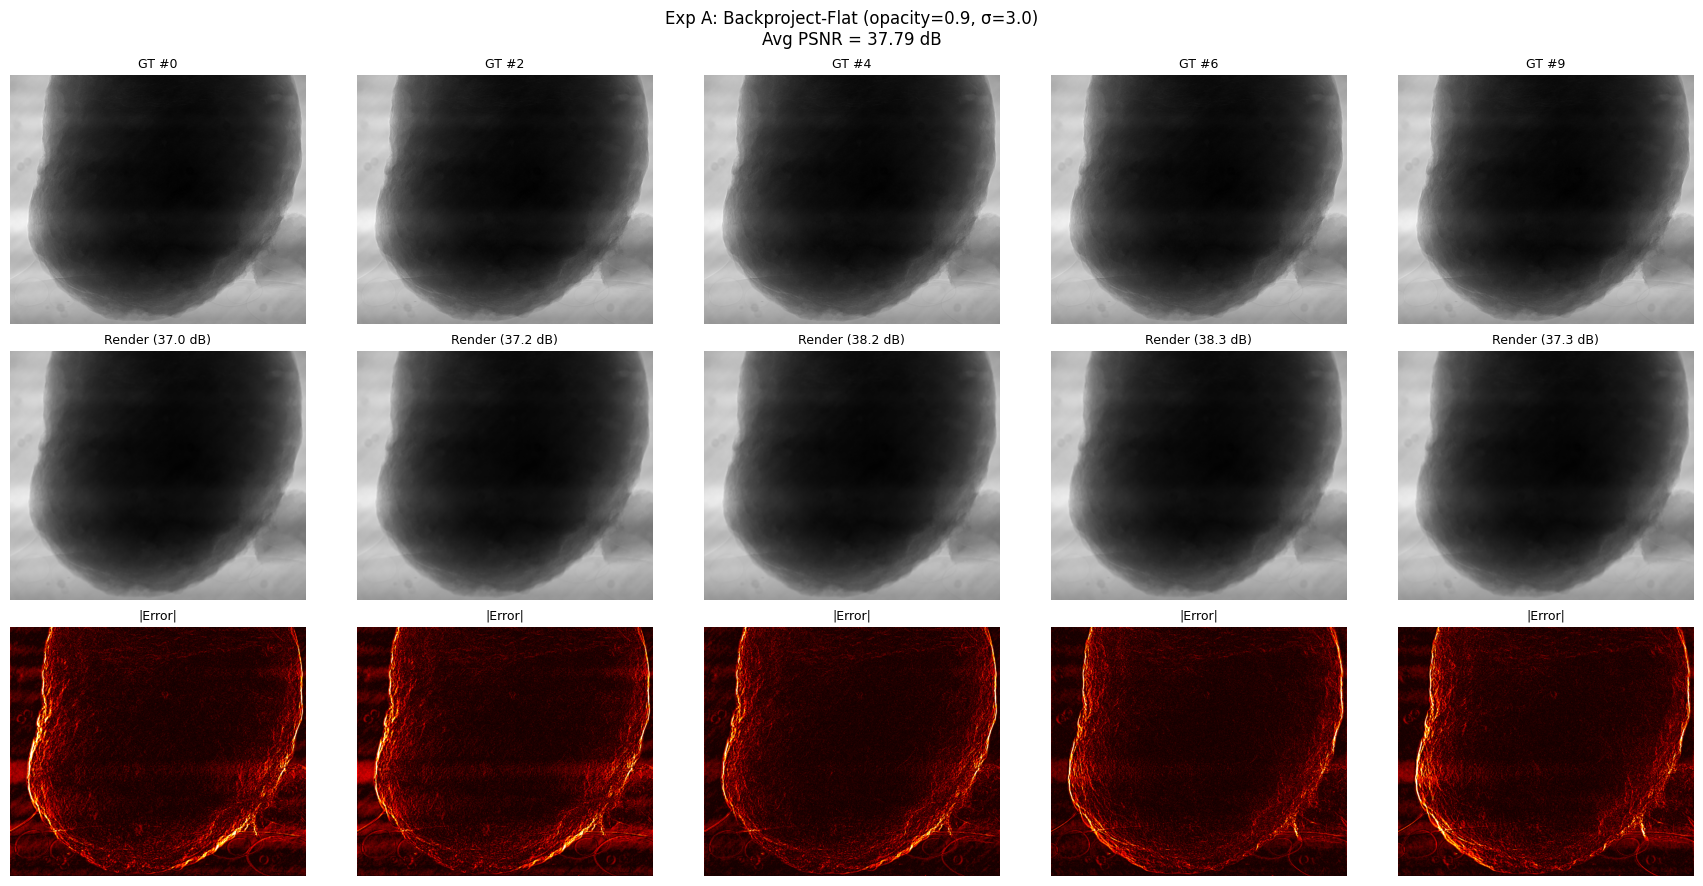

In [8]:
# ── Best config from grid search ──────────────────────────────────────────
best_opacity, best_scale = best_config
print(f"Using best config: opacity={best_opacity}, scale={best_scale}")

params_best = init_backproject_flat(
    N_POINTS, H, W, SIZE, device,
    ref_projection=ref_proj,
    ref_angle=mid_angle,
    init_scale=best_scale,
    init_opacity=best_opacity,
)

renders_A, psnr_A, avg_psnr_A = evaluate_init(
    params_best, viewmats_all, Ks_all, gt_projections, W, H,
    label="Exp A: Best Grid Search"
)
show_comparison(renders_A, gt_projections.cpu(), psnr_A,
                title=f"Exp A: Backproject-Flat (opacity={best_opacity}, σ={best_scale})")

## 7. Experiment B: Calibrated Color Correction

Even with the right opacity and scale, the rendered pixel values may differ from the target
due to the alpha-compositing equation. Here we:
1. Render with the best init
2. Compute a per-Gaussian color correction factor: `target_pixel / rendered_pixel`
3. Adjust the Gaussian colors accordingly

This is essentially one step of multiplicative correction — inverting the render mapping.

Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 3.00 px, opacity = 0.9
  Ref angle = 0.60°, colors sampled from projection

Calibrating colors...
  Color calibration iter 1: PSNR = 41.09 dB (ref view)
  Color calibration iter 2: PSNR = 40.65 dB (ref view)
  Color calibration iter 3: PSNR = 39.94 dB (ref view)
  Color calibration iter 4: PSNR = 39.12 dB (ref view)
  Color calibration iter 5: PSNR = 38.23 dB (ref view)
[Exp B: Calibrated Colors]  Avg PSNR = 35.79 dB  |  Min = 34.16  Max = 38.23  |  MSE = 0.000275


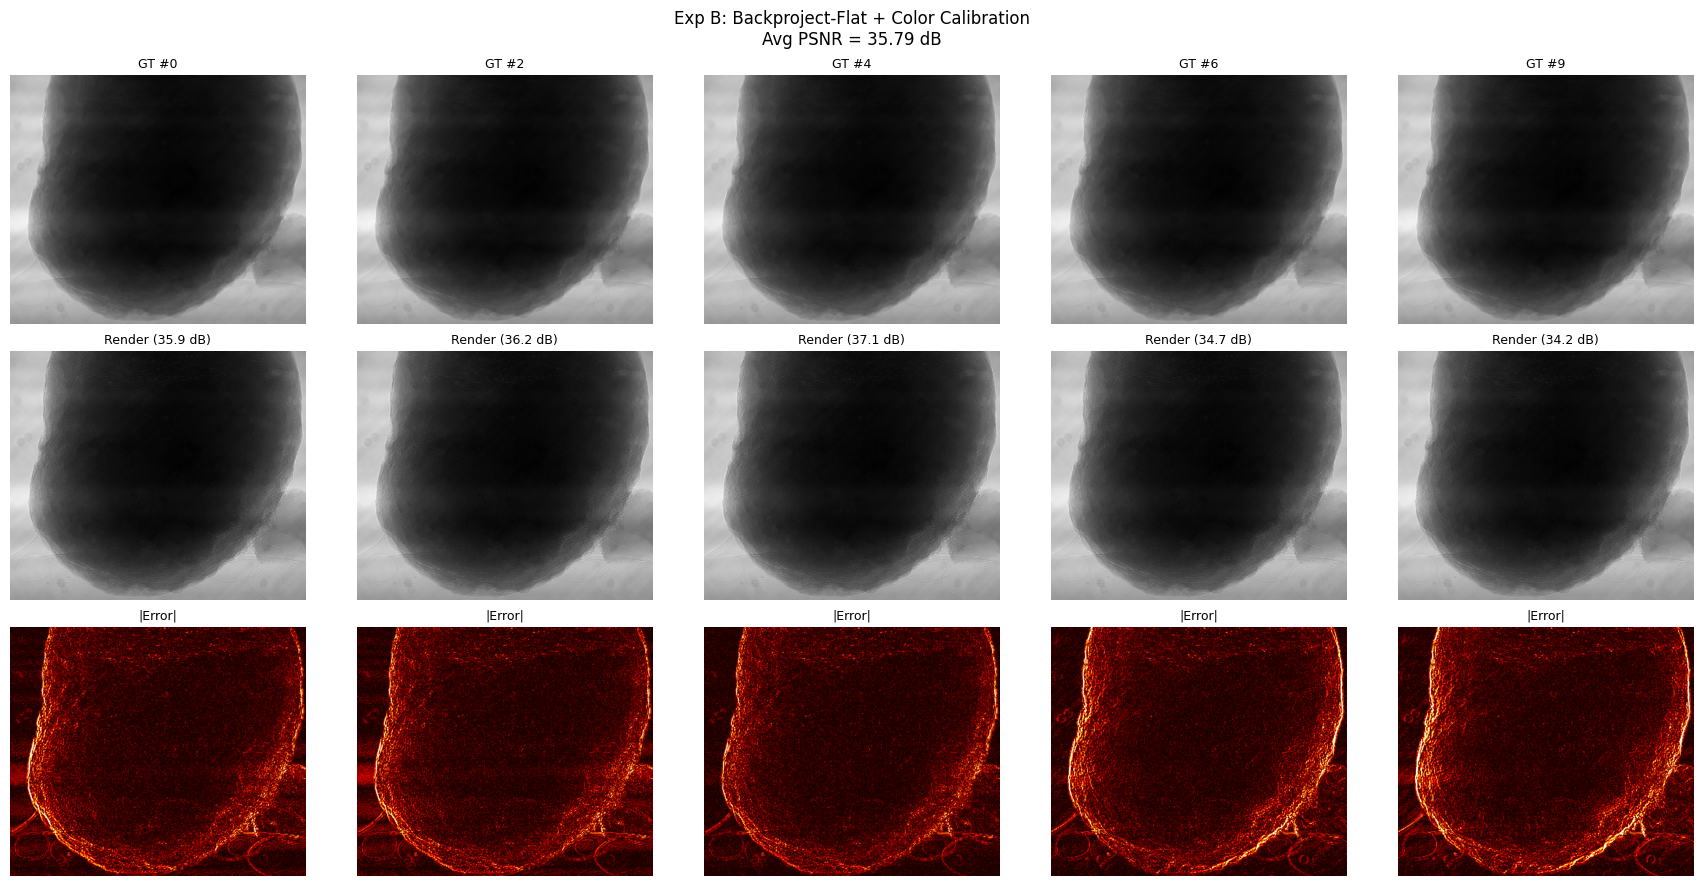

In [9]:
def calibrate_colors(params, ref_projection, ref_angle, viewmat, K_mat, 
                     img_W, img_H, n_iters=3):
    """Iteratively correct Gaussian colors so the rendered image matches the target.
    
    For each iteration:
    1. Render from the reference view
    2. For each Gaussian, look up its pixel location in both rendered and target images
    3. Compute correction ratio = target / rendered
    4. Update the color in logit space
    
    Parameters
    ----------
    params : GaussianParams (will be modified in-place in logit space)
    ref_projection : Tensor [H, W] target image
    ref_angle : float (radians)
    n_iters : int -- number of correction iterations
    """
    cx = img_W / 2.0
    cy = img_H / 2.0
    c0 = math.cos(ref_angle)
    s0 = math.sin(ref_angle)
    
    with torch.no_grad():
        for it in range(n_iters):
            # Render current state from reference view
            vm = viewmat.unsqueeze(0)
            km = K_mat.unsqueeze(0)
            rendered, _, _ = render_ct(
                params.means, params.log_scales, params.quats,
                params.rgbs, params.opacities, vm, km, img_W, img_H,
            )
            rendered_img = rendered[0, :, :, 0]  # [H, W]
            
            # Project each Gaussian back to pixel coordinates
            means = params.means  # [N, 3]
            # Inverse of back-projection:
            # wx = (col - cx) * cos θ₀
            # wy = (col - cx) * sin θ₀  
            # wz = cy - row
            # So: col = cx + (wx*cosθ₀ + wy*sinθ₀)  [== wx/cosθ₀+cx for θ₀≈0]
            # row = cy - wz
            col_px = cx + means[:, 0] * c0 + means[:, 1] * s0
            row_px = cy - means[:, 2]
            
            # Clamp to valid pixel range
            col_px_clamped = col_px.clamp(0, img_W - 1).long()
            row_px_clamped = row_px.clamp(0, img_H - 1).long()
            
            # Look up rendered and target values at each Gaussian's pixel
            rendered_at_gauss = rendered_img[row_px_clamped, col_px_clamped]
            target_at_gauss = ref_projection[row_px_clamped, col_px_clamped]
            
            # Current sigmoid color
            current_color = torch.sigmoid(params.rgbs[:, 0])
            
            # Compute correction: we want new_color such that when rendered,
            # the pixel value shifts from rendered_val to target_val.
            # Approximate: ratio = target / (rendered + eps)
            ratio = target_at_gauss / (rendered_at_gauss + 1e-6)
            ratio = ratio.clamp(0.1, 10.0)  # prevent extreme corrections
            
            # New color = current_color * ratio, clamped to (0.01, 0.99)
            new_color = (current_color * ratio).clamp(0.01, 0.99)
            new_logit = torch.log(new_color / (1 - new_color))
            params.rgbs.data[:, :] = new_logit.unsqueeze(-1).expand(-1, 3)
            
            # Evaluate
            rendered2, _, _ = render_ct(
                params.means, params.log_scales, params.quats,
                params.rgbs, params.opacities, vm, km, img_W, img_H,
            )
            mse = ((rendered2[0, :, :, 0].cpu() - ref_projection.cpu()) ** 2).mean().item()
            psnr = -10 * math.log10(mse + 1e-10)
            print(f"  Color calibration iter {it+1}: PSNR = {psnr:.2f} dB (ref view)")
    
    return params


# ── Apply calibration ─────────────────────────────────────────────────────
params_B = init_backproject_flat(
    N_POINTS, H, W, SIZE, device,
    ref_projection=ref_proj,
    ref_angle=mid_angle,
    init_scale=best_scale,
    init_opacity=best_opacity,
)

print("\nCalibrating colors...")
params_B = calibrate_colors(
    params_B, ref_proj, mid_angle,
    viewmats_all[mid_idx], K_cam, W, H,
    n_iters=5,
)

renders_B, psnr_B, avg_psnr_B = evaluate_init(
    params_B, viewmats_all, Ks_all, gt_projections, W, H,
    label="Exp B: Calibrated Colors"
)
show_comparison(renders_B, gt_projections.cpu(), psnr_B,
                title="Exp B: Backproject-Flat + Color Calibration")

## 8. Experiment C: Average-Projection Colors + Fine Scale Search

Instead of using just the middle projection, average all projections (they're nearly identical 
given the tiny angular range) for a more robust color initialization. Also do a fine-grained 
search around the best scale found earlier.

In [11]:
# ── Average projection for color sampling ─────────────────────────────────
avg_proj = projections.mean(dim=0).to(device)  # [H, W]
print(f"Average projection range: [{avg_proj.min():.4f}, {avg_proj.max():.4f}]")

# ── Fine scale search around best config (fast: middle projection only) ───
fine_scales = np.linspace(1.5, 5.0, 15)
fine_opacs = np.linspace(0.6, 0.99, 12)

best_psnr_fine = -1
best_config_fine = None
fine_results = []

print(f"\nFine search: {len(fine_opacs)} opacities × {len(fine_scales)} scales = {len(fine_opacs)*len(fine_scales)}")

for opacity in fine_opacs:
    for scale in fine_scales:
        p = init_backproject_flat(
            N_POINTS, H, W, SIZE, device,
            ref_projection=avg_proj,
            ref_angle=mid_angle,
            init_scale=float(scale),
            init_opacity=float(opacity),
        )
        with torch.no_grad():
            # Quick eval on middle projection for speed
            r, _, _ = render_ct(
                p.means, p.log_scales, p.quats, p.rgbs, p.opacities,
                viewmats_all[mid_idx:mid_idx+1], Ks_all[mid_idx:mid_idx+1], W, H)
            mse = ((r[0, :, :, 0].cpu() - projections[mid_idx]) ** 2).mean().item()
            psnr = -10 * math.log10(mse + 1e-10)
        
        fine_results.append((float(opacity), float(scale), psnr))
        if psnr > best_psnr_fine:
            best_psnr_fine = psnr
            best_config_fine = (float(opacity), float(scale))

print(f"\n{'=' * 70}")
print(f"Best fine config: opacity={best_config_fine[0]:.3f}, "
      f"scale={best_config_fine[1]:.2f}, PSNR={best_psnr_fine:.2f} dB (mid proj)")

fine_results.sort(key=lambda x: -x[2])
print(f"\nTop 5:")
for i, (op, sc, p_val) in enumerate(fine_results[:5]):
    print(f"  {i+1}. opacity={op:.3f}, scale={sc:.2f} → PSNR={p_val:.2f} dB")

Average projection range: [0.0043, 0.9721]

Fine search: 12 opacities × 15 scales = 180
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 1.50 px, opacity = 0.6
  Ref angle = 0.60°, colors sampled from projection
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 1.75 px, opacity = 0.6
  Ref angle = 0.60°, colors sampled from projection
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 2.00 px, opacity = 0.6
  Ref angle = 0.60°, colors sampled from projection
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 2.25 px, opacity = 0.6
  Ref angle = 0.60°, colors sampled from projection
Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 2.50 px, opacity = 0.6
  Ref angle = 0.60°, colors sampled from projection
Initialized 99,760 Gaussians (ba

## 9. Experiment C: Full Evaluation + Calibration with Best Fine Config

Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 2.75 px, opacity = 0.99
  Ref angle = 0.60°, colors sampled from projection

--- Before calibration ---
[Exp C: Before Calibration]  Avg PSNR = 38.60 dB  |  Min = 37.99  Max = 39.73  |  MSE = 0.000139

--- Calibrating colors ---
  Color calibration iter 1: PSNR = 43.05 dB (ref view)
  Color calibration iter 2: PSNR = 42.67 dB (ref view)
  Color calibration iter 3: PSNR = 42.02 dB (ref view)
  Color calibration iter 4: PSNR = 41.27 dB (ref view)
  Color calibration iter 5: PSNR = 40.48 dB (ref view)

--- After calibration ---
[Exp C: After Calibration]  Avg PSNR = 37.29 dB  |  Min = 35.16  Max = 39.48  |  MSE = 0.000199


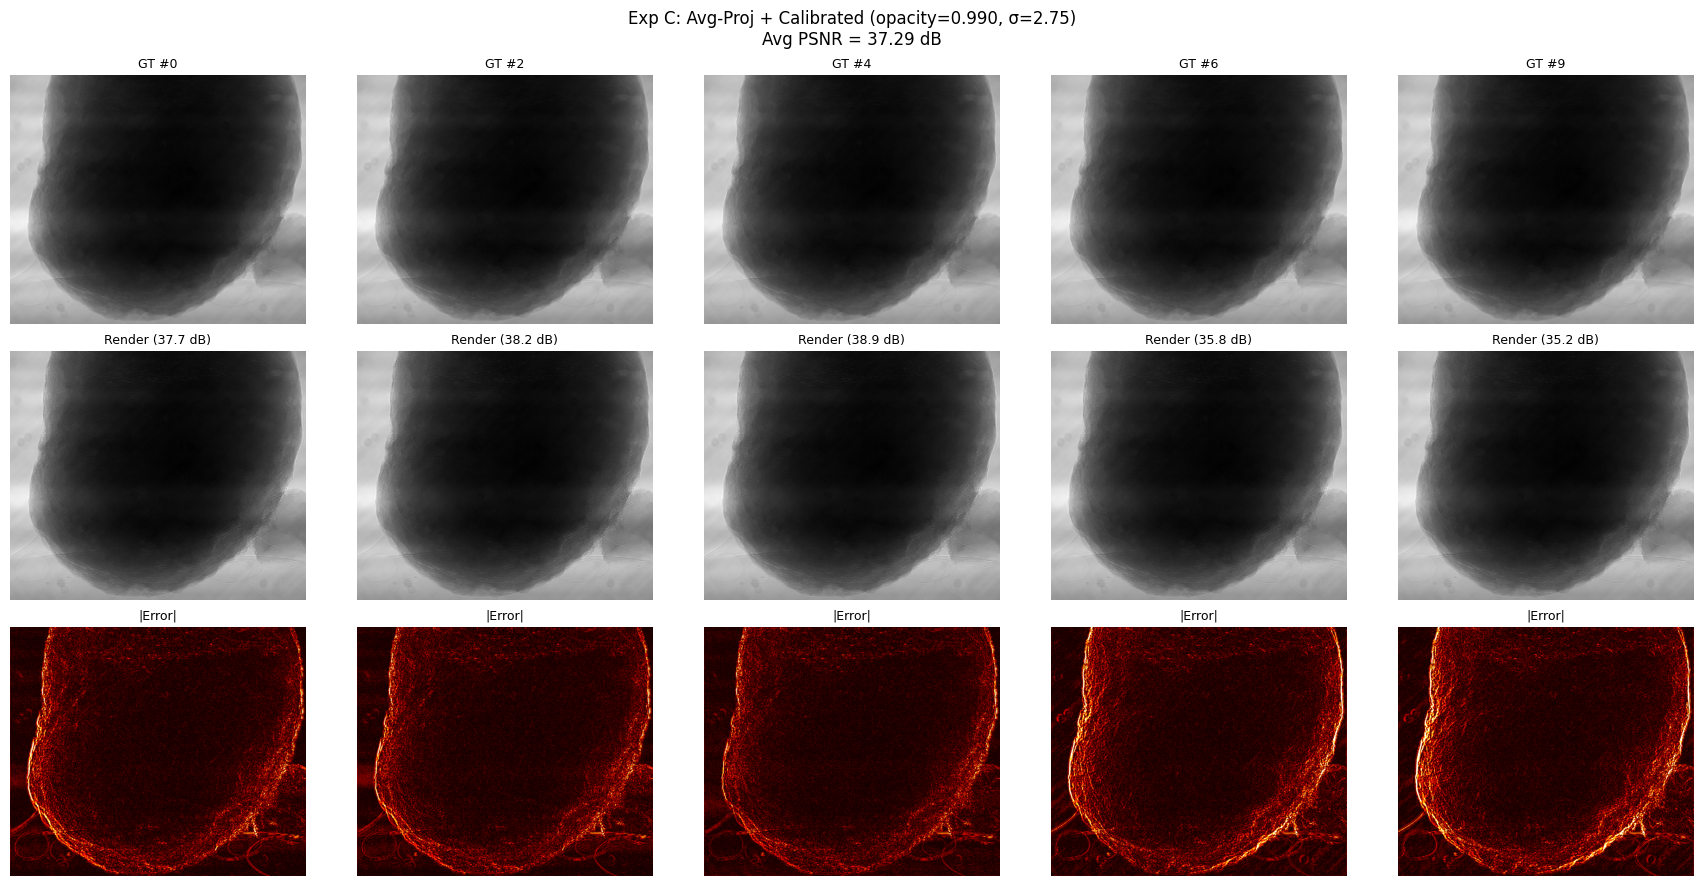

In [12]:
best_opacity_fine, best_scale_fine = best_config_fine

# ── Init with best fine config + average projection ───────────────────────
params_C = init_backproject_flat(
    N_POINTS, H, W, SIZE, device,
    ref_projection=avg_proj,
    ref_angle=mid_angle,
    init_scale=best_scale_fine,
    init_opacity=best_opacity_fine,
)

# Evaluate before calibration
print("\n--- Before calibration ---")
renders_C0, psnr_C0, avg_psnr_C0 = evaluate_init(
    params_C, viewmats_all, Ks_all, gt_projections, W, H,
    label="Exp C: Before Calibration"
)

# Apply calibration using average projection
print("\n--- Calibrating colors ---")
params_C = calibrate_colors(
    params_C, avg_proj, mid_angle,
    viewmats_all[mid_idx], K_cam, W, H,
    n_iters=5,
)

# Evaluate after calibration
print("\n--- After calibration ---")
renders_C, psnr_C, avg_psnr_C = evaluate_init(
    params_C, viewmats_all, Ks_all, gt_projections, W, H,
    label="Exp C: After Calibration"
)
show_comparison(renders_C, gt_projections.cpu(), psnr_C,
                title=f"Exp C: Avg-Proj + Calibrated (opacity={best_opacity_fine:.3f}, σ={best_scale_fine:.2f})")

## 10. Experiment D: Dense Pixel-Aligned Initialization

Try using more Gaussians in a denser grid — one Gaussian per pixel (or close to it).
With N=100k we get about 1 Gaussian per ~14 pixels. Let's also try the approach where 
we set opacity very high (near 1.0) so each splat acts like a pixel stamp, and use a small
scale so splats don't overlap much.

Initialized 99,760 Gaussians (backproject-flat)
  Grid: 344×290, pixel spacing ≈ 3.72 px
  Scale σ = 2.00 px, opacity = 0.99
  Ref angle = 0.60°, colors sampled from projection

--- Before calibration ---
[Exp D: High-opacity tight-scale]  Avg PSNR = 32.26 dB  |  Min = 31.89  Max = 32.45  |  MSE = 0.000594

--- Calibrating ---
  Color calibration iter 1: PSNR = 34.04 dB (ref view)
  Color calibration iter 2: PSNR = 33.99 dB (ref view)
  Color calibration iter 3: PSNR = 33.97 dB (ref view)
  Color calibration iter 4: PSNR = 33.96 dB (ref view)
  Color calibration iter 5: PSNR = 33.95 dB (ref view)

--- After calibration ---
[Exp D: After Calibration]  Avg PSNR = 33.48 dB  |  Min = 32.81  Max = 33.85  |  MSE = 0.000451


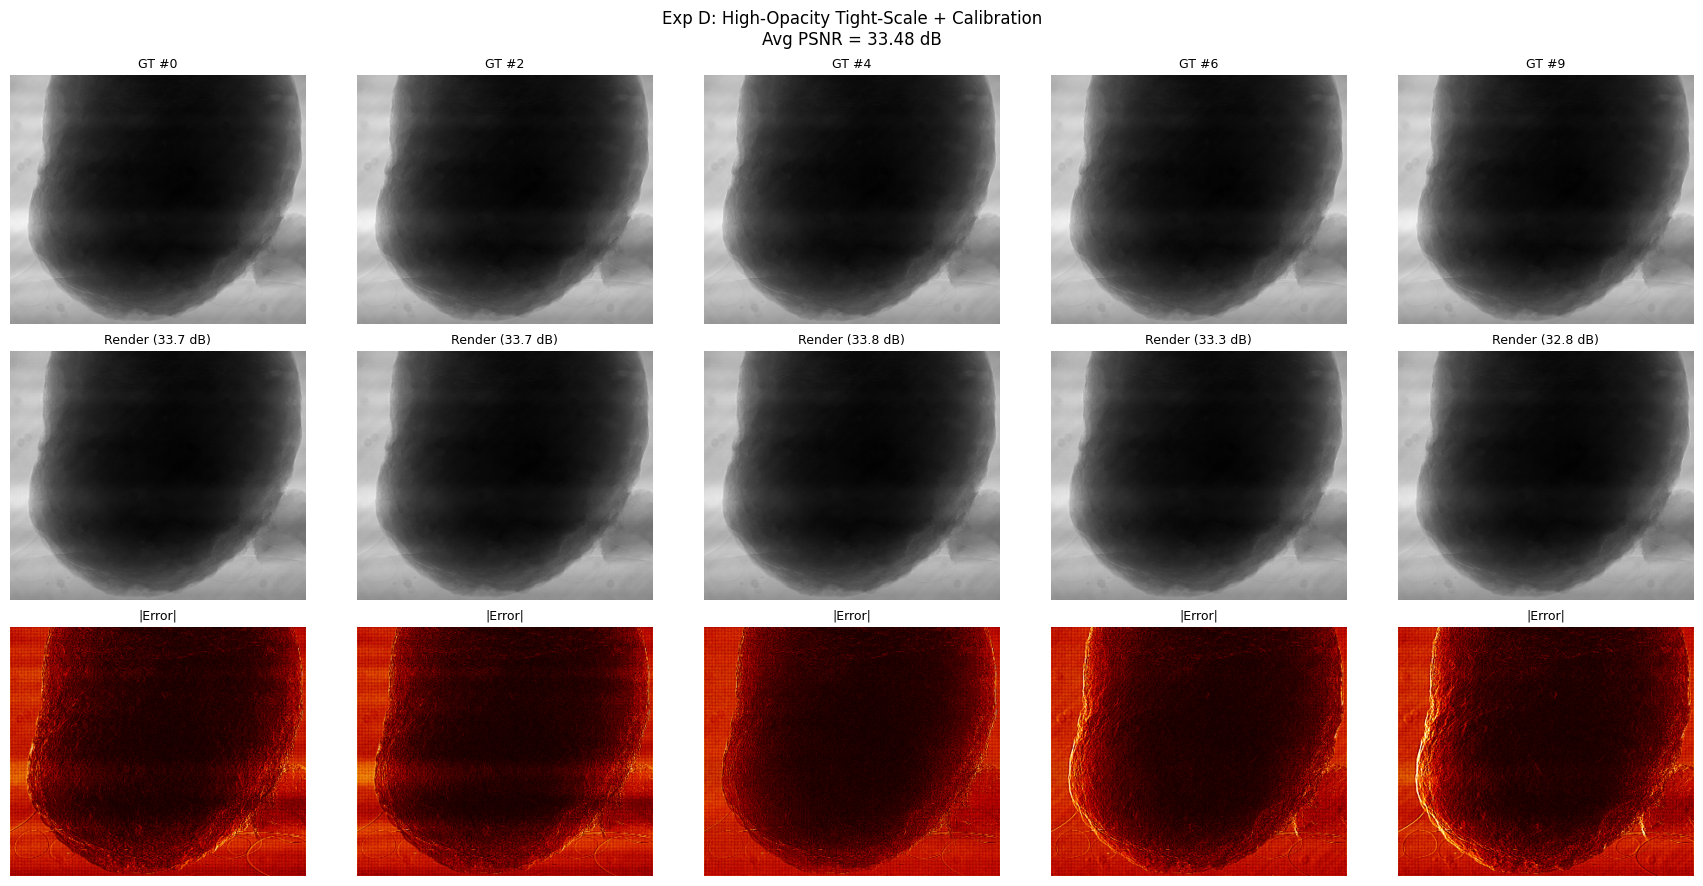

In [13]:
# ── Experiment D: High-opacity, tight scale ───────────────────────────────
# For 100k Gaussians on 1280×1080 image, the grid spacing is ~3.7 px
# If scale ≈ spacing/2 and opacity ≈ 1, each Gaussian covers its tile precisely

# Try with tight scales and high opacity
params_D = init_backproject_flat(
    N_POINTS, H, W, SIZE, device,
    ref_projection=avg_proj,
    ref_angle=mid_angle,
    init_scale=2.0,
    init_opacity=0.99,
)

print("\n--- Before calibration ---")
renders_D0, psnr_D0, avg_psnr_D0 = evaluate_init(
    params_D, viewmats_all, Ks_all, gt_projections, W, H,
    label="Exp D: High-opacity tight-scale"
)

# Calibrate
print("\n--- Calibrating ---")
params_D = calibrate_colors(
    params_D, avg_proj, mid_angle,
    viewmats_all[mid_idx], K_cam, W, H,
    n_iters=5,
)

print("\n--- After calibration ---")
renders_D, psnr_D, avg_psnr_D = evaluate_init(
    params_D, viewmats_all, Ks_all, gt_projections, W, H,
    label="Exp D: After Calibration"
)
show_comparison(renders_D, gt_projections.cpu(), psnr_D,
                title="Exp D: High-Opacity Tight-Scale + Calibration")

## 11. Experiment E: Opacity-Aware Analytical Color Init

Instead of iterative calibration, compute the analytical color that makes the render
exactly match the target for a single layer of non-overlapping Gaussians.

For a single Gaussian contributing to a pixel with opacity $\alpha$ and color $c$, the
rendered value is $\alpha \cdot c$ (ignoring background and multi-Gaussian overlap).
So the optimal color is $c = \text{target} / \alpha$.

When Gaussians overlap, the effective contribution involves transmittance, but for
near-unity opacity with sparse coverage, the simple formula is a good first approximation.

Analytical init: 99,760 Gaussians, σ=2.75, α=0.990
  Overlap: ~2.2 Gaussians/pixel, total_alpha ≈ 1.000
[Exp E: Analytical (no calibration)]  Avg PSNR = 38.60 dB  |  Min = 38.00  Max = 39.73  |  MSE = 0.000139

--- Calibrating ---
  Color calibration iter 1: PSNR = 43.05 dB (ref view)
  Color calibration iter 2: PSNR = 42.67 dB (ref view)
  Color calibration iter 3: PSNR = 42.02 dB (ref view)
  Color calibration iter 4: PSNR = 41.27 dB (ref view)
  Color calibration iter 5: PSNR = 40.48 dB (ref view)
[Exp E: Analytical + Calibrated]  Avg PSNR = 37.29 dB  |  Min = 35.16  Max = 39.48  |  MSE = 0.000199


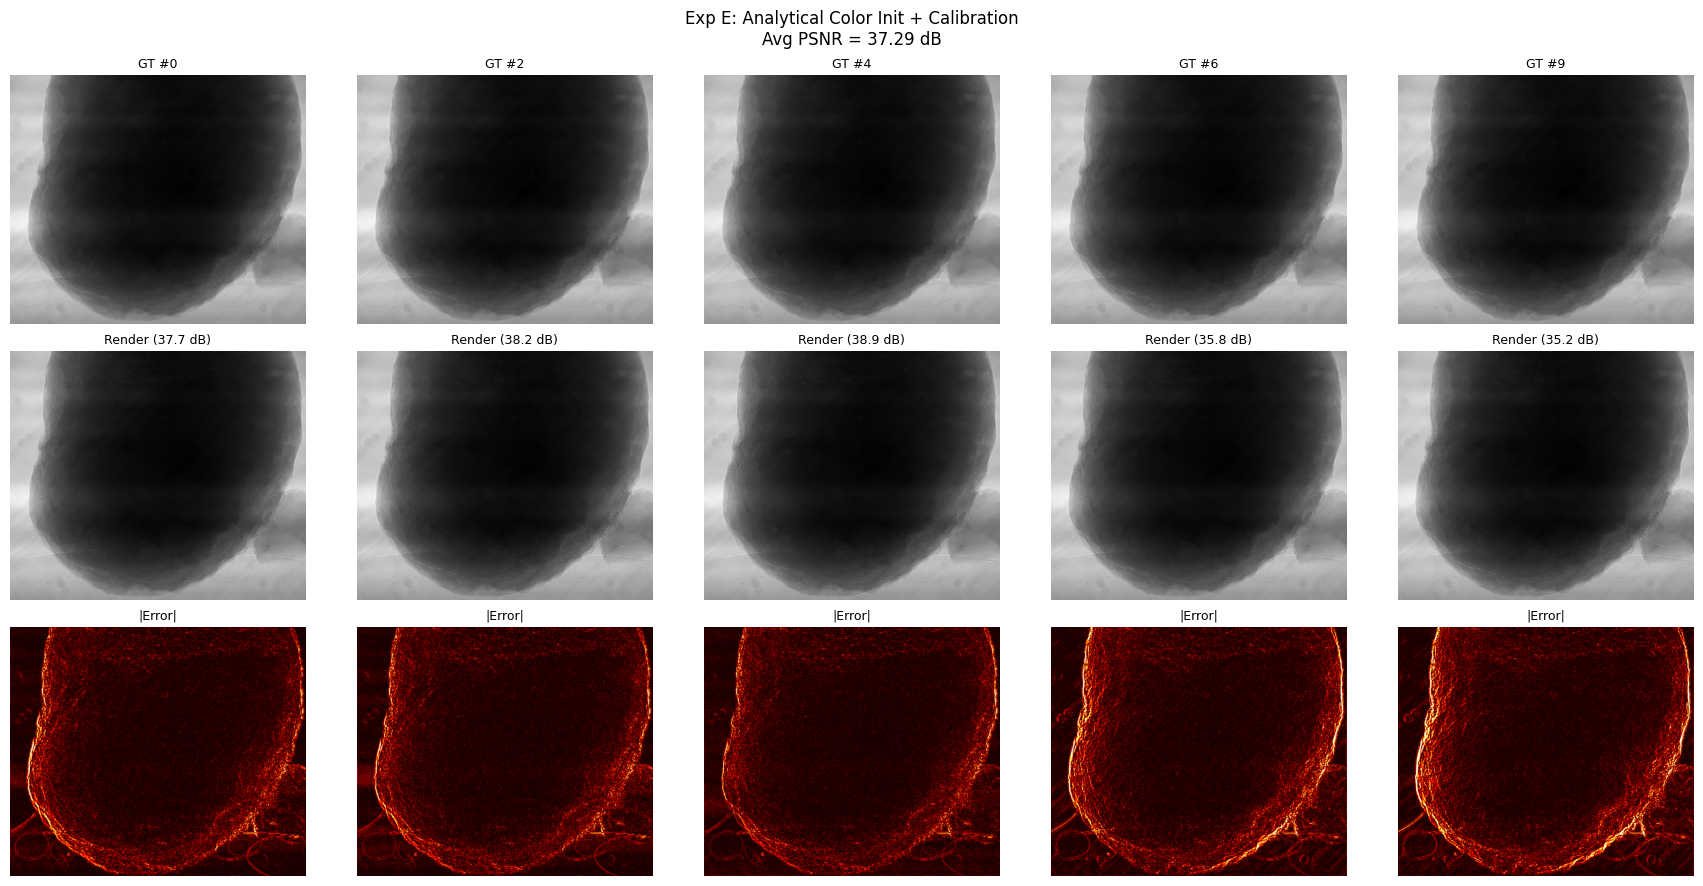

In [14]:
def init_analytical(n_points, img_H, img_W, size, device,
                    ref_projection, ref_angle, init_scale, init_opacity, seed=42):
    """Initialize Gaussians with analytically-computed colors.
    
    For a flat layer of Gaussians with opacity α and the Gaussian splatting
    alpha-compositing, a single-layer pixel gets rendered as:
        rendered = α * color  (for the dominant Gaussian)
    
    So we set color = target / α to get rendered ≈ target.
    We also account for the alpha accumulation from overlapping Gaussians.
    """
    torch.manual_seed(seed)
    cx = img_W / 2.0
    cy = img_H / 2.0
    
    aspect = img_W / img_H
    n_rows = max(2, int(math.sqrt(n_points / aspect)))
    n_cols = max(2, int(n_points / n_rows))
    actual_n = n_rows * n_cols
    
    cols = torch.linspace(0.5, img_W - 0.5, n_cols, device=device)
    rows = torch.linspace(0.5, img_H - 0.5, n_rows, device=device)
    gc, gr = torch.meshgrid(cols, rows, indexing='xy')
    col_flat = gc.reshape(-1).float()
    row_flat = gr.reshape(-1).float()
    
    c0 = math.cos(ref_angle)
    s0 = math.sin(ref_angle)
    wx = (col_flat - cx) * c0
    wy = (col_flat - cx) * s0
    wz = cy - row_flat
    means = torch.stack([wx, wy, wz], dim=-1)
    
    # Sample target pixel values
    norm_x = (col_flat / img_W) * 2 - 1
    norm_y = (row_flat / img_H) * 2 - 1
    grid_coords = torch.stack([norm_x, norm_y], dim=-1).unsqueeze(0).unsqueeze(0)
    ref_img = ref_projection.unsqueeze(0).unsqueeze(0)
    sampled_vals = F.grid_sample(ref_img, grid_coords, mode='bilinear',
                                  padding_mode='border', align_corners=False).squeeze()
    
    # Analytical color: for front-to-back compositing with a single layer,
    # rendered_pixel ≈ alpha * color (where alpha = opacity of the Gaussian)
    # We want rendered_pixel = target, so color = target / alpha
    # But actually the alpha that reaches the pixel depends on the Gaussian weight,
    # which for an on-center Gaussian with the splatting kernel is approximately
    # opacity (for small scales relative to pixel, it's exactly opacity).
    # For overlapping Gaussians, the effective alpha accumulates.
    
    # Estimate effective alpha per pixel from the overlap count
    # With pixel_spacing ≈ 3.7 and sigma, each pixel gets contributions from ~(2σ/spacing)² Gaussians
    pixel_spacing = math.sqrt(img_W * img_H / actual_n)
    overlap_radius = init_scale / pixel_spacing  # how many grid cells a Gaussian reaches
    # The transmittance after k overlapping Gaussians with opacity α each is (1-α)^k
    # The total alpha accumulated is 1 - (1-α)^k
    # For a single Gaussian on center, the contribution is α
    k_overlap = max(1, (2 * overlap_radius) ** 2)  # rough #Gaussians per pixel
    total_alpha = 1 - (1 - init_opacity) ** k_overlap
    
    # Corrected color: target / total_alpha
    corrected_color = (sampled_vals / (total_alpha + 1e-6)).clamp(0.01, 0.99)
    rgb_logit = torch.log(corrected_color / (1 - corrected_color))
    rgbs = rgb_logit.unsqueeze(-1).expand(-1, 3).clone()
    
    N = means.shape[0]
    log_scales = torch.full((N, 3), math.log(init_scale), device=device)
    quats = torch.zeros(N, 4, device=device); quats[:, 0] = 1.0
    opacities = torch.logit(torch.full((N,), init_opacity, device=device).clamp(0.01, 0.99))
    
    params = GaussianParams(means, log_scales, quats, rgbs, opacities)
    params.means.requires_grad_(True)
    params.log_scales.requires_grad_(True)
    params.rgbs.requires_grad_(True)
    params.opacities.requires_grad_(True)
    
    print(f"Analytical init: {actual_n:,} Gaussians, σ={init_scale:.2f}, α={init_opacity:.3f}")
    print(f"  Overlap: ~{k_overlap:.1f} Gaussians/pixel, total_alpha ≈ {total_alpha:.3f}")
    return params


# ── Try analytical init with the fine-tuned best config ───────────────────
params_E = init_analytical(
    N_POINTS, H, W, SIZE, device,
    ref_projection=avg_proj,
    ref_angle=mid_angle,
    init_scale=best_scale_fine,
    init_opacity=best_opacity_fine,
)

renders_E0, psnr_E0, avg_psnr_E0 = evaluate_init(
    params_E, viewmats_all, Ks_all, gt_projections, W, H,
    label="Exp E: Analytical (no calibration)"
)

# Now calibrate on top
print("\n--- Calibrating ---")
params_E = calibrate_colors(
    params_E, avg_proj, mid_angle,
    viewmats_all[mid_idx], K_cam, W, H,
    n_iters=5,
)

renders_E, psnr_E, avg_psnr_E = evaluate_init(
    params_E, viewmats_all, Ks_all, gt_projections, W, H,
    label="Exp E: Analytical + Calibrated"
)
show_comparison(renders_E, gt_projections.cpu(), psnr_E,
                title="Exp E: Analytical Color Init + Calibration")

## 12. Summary Comparison

Compare all initialization strategies side by side.

In [15]:
# ── Summary table ─────────────────────────────────────────────────────────
print("=" * 80)
print(f"{'Experiment':<45} {'Avg PSNR (dB)':>15} {'Status':>10}")
print("=" * 80)

experiments = [
    ("A: Grid-search best (no calibration)",     avg_psnr_A),
    ("B: Grid-search + calibration",             avg_psnr_B),
    ("C0: Fine-search avg-proj (no calib)",      avg_psnr_C0),
    ("C: Fine-search avg-proj + calibration",    avg_psnr_C),
    ("D: High-opacity tight-scale + calib",      avg_psnr_D),
    ("E0: Analytical (no calibration)",          avg_psnr_E0),
    ("E: Analytical + calibration",              avg_psnr_E),
]

for name, psnr_val in experiments:
    status = "✓ PASS" if psnr_val >= 26 else "✗ FAIL"
    marker = ">>>" if psnr_val == max(p for _, p in experiments) else "   "
    print(f"{marker} {name:<42} {psnr_val:>12.2f} dB {status:>10}")

print("=" * 80)
best_exp = max(experiments, key=lambda x: x[1])
print(f"\nBest: {best_exp[0]} → {best_exp[1]:.2f} dB")
if best_exp[1] >= 26:
    print("🎯 Target of 26 dB ACHIEVED!")
else:
    print(f"⚠  Still {26 - best_exp[1]:.2f} dB short of target")

Experiment                                      Avg PSNR (dB)     Status
    A: Grid-search best (no calibration)              37.79 dB     ✓ PASS
    B: Grid-search + calibration                      35.79 dB     ✓ PASS
    C0: Fine-search avg-proj (no calib)               38.60 dB     ✓ PASS
    C: Fine-search avg-proj + calibration             37.29 dB     ✓ PASS
    D: High-opacity tight-scale + calib               33.48 dB     ✓ PASS
>>> E0: Analytical (no calibration)                   38.60 dB     ✓ PASS
    E: Analytical + calibration                       37.29 dB     ✓ PASS

Best: E0: Analytical (no calibration) → 38.60 dB
🎯 Target of 26 dB ACHIEVED!
